In [ ]:
# script for computing NN for a homogeneous half-space or full space
# for spherical cavities and single plane wave
import numpy as np
import os
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from scipy.io import savemat
from scipy.io import loadmat
from scipy.integrate import quad, tplquad, dblquad
import scipy.constants as const

from pysurf96 import surf96
from modules import configLoader
from modules import validateInputs
from modules import createDB
from modules import NNGeometryNN
from modules import gfLoader
from modules import simDisp
from modules import NNCompute

def main():

    # load the config file
    configFile="/home/koley/CavityResults/SphereTutorialConfig/configParseHalfSpaceBodyHomo.ini"
    config = configLoader.load_config(configFile)
    wType = 'Pz' # can be Px, Pz, SV, SHx, SHy
    # load all cavities
    allCavities = configLoader.loadCavities('/home/koley/CavityResults/SphereTutorialConfig/SingleSphCavityHalfSpace.ini')
    validateInputs.validateInputs(config)
    
    splitAll = createDB.createFinalInputs(config)

    print(f"Prepared {splitAll.shape[0]} total runs")
    print(f"Cores available: {config.cpuCoresQseis}")

    results = createDB.runMultiQseis(splitAll, config.inputPath, config.qseisExe, nWorkers = config.cpuCoresQseis)
    
    print("Database generation complete")
    # flag for pure Rayleigh wavefield in homogeneous half-space
    ifRay = config.ifRay
    # flag for plane P and S waves in homogeneous half space
    ifBody = config.ifBody
    # flag for wavefield simulation
    ifFullField = config.ifFullField
    saveHV = config.saveHV
    thickness = config.thickness # units in meters
    vs = config.vS # units in m/s
    vp = config.vP # units in m/s
    rho = config.rho # units in kg/m^3
    rhoAir = config.rhoAir # density of air
    fMin = config.fMin; fMax = config.fMax; df = config.df;# units in Hz
    lambdaFrac = config.lambdaFrac # fraction
    lambdaRes = config.lambdaRes; #must be greater than 4
    
    # given a cuboidal domain should be greater than sqrt of 
    xMaxGF = config.xMaxGF # maximum horizontal offset upto which displacements will be used
    zMaxGF = config.zMaxGF # maximum depth upto which displacements will be used
    maxRec = config.maxRec # same value of number of receivers that qseis can handle in one go check qsglobal.h
    xCenter = config.xCenter; yCenter = config.yCenter
    xMin = xCenter-config.xExtent; xMax = xCenter+config.xExtent # minimum and maximum of the simulation domain in X-direction (EW)
    yMin = yCenter-config.yExtent; yMax = yCenter+config.yExtent # maximum and minimum of the simulation domain in Y-direction (NS)
    zMin = 0.0; zMax = config.zExtent # maximum and minimum of the simulation domain in Z-direction (depth)

    # check if the GFs are generated up to correct hoizontal offsets
    xDiag = (xMax-xMin)*np.sqrt(2); yDiag = (yMax-yMin)*np.sqrt(2);
    if(xMaxGF<xDiag or xMaxGF<yDiag):
        raise ValueError("xMaxGF must be >= sqrt(2)x(xMax-xMin) and sqrt(2)x(yMax-yMin)")

    if(zMaxGF<zMax):
        raise ValueError("zMaxGF must be greater >= zMax")
        
    domXYBounds = (xMin,xMax,yMin,yMax)
    
    refineBoxes = NNGeometryNN.makeRefineBoxesFromCavities(allCavities)
    cubeTopAll = np.zeros((len(allCavities),))
    cubeBotAll = np.zeros((len(allCavities),))
    for boxNo, box in enumerate(refineBoxes):
        cubeTopAll[boxNo] = box.zMin
        cubeBotAll[boxNo] = box.zMax
    cubeTop = min(cubeTopAll)
    cubeBot = max(cubeBotAll)
    # new part added
    
    cavDepthAll = np.zeros((len(allCavities),))
    for cavNo, cav in enumerate(allCavities):    
        if(cav["shape"]=="cuboid"):
            cavDepthAll[cavNo] = cav["zC"]
        elif(cav["shape"] == 'sphere'):
            cavDepthAll[cavNo] = cav["zC"]
        else:
            ValueError('Unsupported cavity type')
    cavDepthUse = min(cavDepthAll)

    print("CubeTop = " + str(cubeTop) +  'CubeBot = ' + str(cubeBot))
    
    itmAC = config.itmAC; itmAB = config.itmAB; etmCA = config.etmCA; etmBA = config.etmBA

    print('itmAC = ' + str(itmAC[0]) + ', ' + str(itmAC[1]) + ', ' + str(itmAC[2]))
    # make itmAC[2] negative, because in the configfile it is positive
    itmACUse = itmAC.copy(); itmACUse[2] = -np.abs(itmACUse[2])
    itmABUse = itmAB.copy(); itmABUse[2] = -np.abs(itmABUse[2])
    etmCAUse = etmCA.copy(); etmCAUse[2] = -np.abs(etmCAUse[2])
    etmBAUse = etmBA.copy(); etmBAUse[2] = -np.abs(etmBAUse[2])

    itmAll = np.vstack((itmACUse,itmABUse, etmCAUse,etmBAUse))
    nTM = len(itmAll[:,0])
    G = const.G
    
    # some other inputs for simDisp
    maxRec = config.maxRec; # same value of number of receivers that qseis can handle in one go check qsglobal.h
    tMax = config.tMax; nSamp = config.nSamp
    
    # specify the folder where you want to write all input files, should have rw access
    # fInpPath is the path where the Green's function database exists
    fInpPath = config.inputPath #like "/data/gravwav/koley/QseisInpN/"
    #fInpPath = "/data/gravwav/koley/SALVUSOut/"

    # outDispPath should have rw access and is used for saving temp displacementy files
    outDispPath = config.outDispPath # like "/data/gravwav/koley/OutDisp/"

    # saves the NN and displacement values per realization
    outDispRea = config.outDispPathRea # like "/data/gravwav/koley/OutDispRea/"
    
    # GF components to be used
    components = ['fh-2.tz', 'fh-2.tr', 'fh-2.tt', 'fz-2.tz', 'fz-2.tr']

    # splitAll is necessary so load it
    nRea = config.nRea # number of realizations

    # this file is created at the time of database generation
    splitFileName = fInpPath + 'splitAll.mat'
    splitMat = loadmat(splitFileName)
    splitAll = splitMat['splitAll']

    # source distribution parameters
    R1 = config.R1; R2 = config.R2
    nSrc = config.nSrc
    srcDistri = config.srcDistri
    scaleVH = config.scaleVH
    # flag if NN is computed directly without writing the displacemnet field
    onFlyNN = config.onFlyNN 

    # number of CPUs to be used for displacement and NN simulation
    nCPUDisp = config.cpuCoresDisp
    nCPUNN = config.cpuCoresNN
    computeStrategy = config.computeStrategy

    # frequency axis to be used by simDisp
    freqOut, idxFreq, df_native = simDisp.getFreqGrid(tMax, nSamp, fMin, fMax, df)
    nFreq = len(freqOut)

    splitAllNew, tVecN = gfLoader.assembleQseisRuns(splitAll, fInpPath, components, outPath=None, fIndices=idxFreq, minVel=100.0)
    #splitAllNew = np.load(os.path.join(fInpPath,'splitAllNew.npy'))

    # in case only Rayleigh waves in homogeneous half space is used, Rayleigh wave phase velocity is needed
    if(ifRay):
        periods = 1/freqOut
        vR = surf96(thickness,vp,vs,rho,periods,wave="rayleigh",mode=1,velocity="phase",flat_earth=True)
    else:
        vR = None
    # two depth points for scaling, displacement saved per realization
    zList = [0.0,cavDepthUse]
    
    # generate the grid size required
    gridSize = NNCompute.getGridSize(thickness,vp, vs, rho, fMin, fMax, lambdaFrac, lambdaRes)
    
    print('grid size in each layer before partitioning = ' + str(gridSize))
    
    # create the layers and partition
    layers, vp2, vs2, rho2, gridSize2 = NNGeometryNN.createAllLayers(xMin, xMax, yMin, yMax, thickness,
                                                                     zMax,vp,vs,rho,gridSize,cubeTop,cubeBot)
    print('New gridSize after partioning = '+ str(gridSize2))

    print('Total number of layers = ' + str(len(layers)))
    nLayers = len(layers)
    
    for reaNo in range(0,nRea):
        print('Doing realization = ' +str(reaNo))
        # get the source distribution per realization
        xSrc, ySrc, azSrc, srcMeta =  simDisp.genAmbSrc(nSrc , mode = srcDistri, R1 = R1, R2 = R2, xMin=xMin, xMax=xMax, yMin=yMin,
                                           yMax=yMax, randomPhase=True, freqDependent=True, nFreq=nFreq, decoupledHV=config.decoupledHV,
                                           scaleVH = scaleVH)
        
        # in case the body wave in homogeneous half-space flag is turned on
        if(ifBody):
            metaBody = simDisp.genBodySrc(nSrc, nFreq, eP = 0.1, eS = 0.9)
            
            if(wType == 'Px'):
                # P wave along +x
                metaBody["thetaP"] = np.array([0.0])
                metaBody["muP"] = np.array([0.0])

                # Amplitude and phase for the P-wave
                metaBody["ampP"] = 1.0 * np.ones((1, nFreq))
                metaBody["phaseP"] = 0.0 * np.ones((1, nFreq))

                # Keep one dummy S-wave so your existing loops still work,
                # but set its amplitude to zero.
                metaBody["thetaS"] = np.array([0.0])
                metaBody["muS"] = np.array([0.0])
                metaBody["psiS"] = np.array([0.0])
                metaBody["ampS"] = np.zeros((1, nFreq))
                metaBody["phaseS"] = np.zeros((1, nFreq))
            
            elif(wType=='Pz'):
            
                # P-wave propagating along +z

                metaBody["thetaP"] = np.array([0.0])
                metaBody["muP"]    = np.array([1.0])   # +z direction

                # Amplitude and phase for the P-wave
                metaBody["ampP"]   = np.ones((1, nFreq))
                metaBody["phaseP"] = np.zeros((1, nFreq))

                # Dummy S-wave with zero amplitude
                metaBody["thetaS"] = np.array([0.0])
                metaBody["muS"]    = np.array([0.0])
                metaBody["psiS"]   = np.array([0.0])
                metaBody["ampS"]   = np.zeros((1, nFreq))
                metaBody["phaseS"] = np.zeros((1, nFreq))
            elif(wType=='SHy'):
                # for SH wave propagating along +y and displacement field along +x
                metaBody["thetaP"] = np.array([0.0])
                metaBody["muP"]    = np.array([0.0])
                metaBody["ampP"]   = np.zeros((1, nFreq))
                metaBody["phaseP"] = np.zeros((1, nFreq))

                # One S/SH wave propagating along +y
                metaBody["thetaS"] = np.array([0.5*np.pi])
                metaBody["muS"]    = np.array([0.0])
                # For uS = +y, psiS = 0 gives polarization +x
                metaBody["psiS"]   = np.array([0.0])
                metaBody["ampS"]   = np.ones((1, nFreq))
                metaBody["phaseS"] = np.zeros((1, nFreq))
                uS = simDisp.rand_dirs(metaBody["thetaS"], metaBody["muS"])
                polS = simDisp.s_polarizations(uS, metaBody["psiS"])
                print("uS =", uS)
                print("polS =", polS)
                print("ampS first few =", metaBody["ampS"][0, :5])
                print("phaseS first few =", metaBody["phaseS"][0, :5])
            elif(wType=='SHx'):
            
                # SH wave propagating along +x and displacement field along +y
                # No P-wave
                metaBody["thetaP"] = np.array([0.0])
                metaBody["muP"]    = np.array([0.0])
                metaBody["ampP"]   = np.zeros((1, nFreq))
                metaBody["phaseP"] = np.zeros((1, nFreq))
                # One S/SH wave propagating along +x
                metaBody["thetaS"] = np.array([0.0])
                metaBody["muS"]    = np.array([0.0])
                # For uS = +x, psiS = pi gives polarization +y
                metaBody["psiS"]   = np.array([np.pi])
                metaBody["ampS"]   = np.ones((1, nFreq))
                metaBody["phaseS"] = np.zeros((1, nFreq))
                uS = simDisp.rand_dirs(metaBody["thetaS"], metaBody["muS"])
                polS = simDisp.s_polarizations(uS, metaBody["psiS"])
                print("uS =", uS)
                print("polS =", polS)
                print("ampS first few =", metaBody["ampS"][0, :5])
                print("phaseS first few =", metaBody["phaseS"][0, :5])
            
            else:
                # SV wave propagating along +x and displacement field along +z
                # No P-wave
                metaBody["thetaP"] = np.array([0.0])
                metaBody["muP"]    = np.array([0.0])
                metaBody["ampP"]   = np.zeros((1, nFreq))
                metaBody["phaseP"] = np.zeros((1, nFreq))

                # One S/SV wave propagating along +x
                metaBody["thetaS"] = np.array([0.0])
                metaBody["muS"]    = np.array([0.0])

                # For uS = +x, psiS = 3*pi/2 gives polarization +z
                metaBody["psiS"]   = np.array([1.5*np.pi])

                metaBody["ampS"]   = np.ones((1, nFreq))
                metaBody["phaseS"] = np.zeros((1, nFreq))

                nSrc = 1

                uS = simDisp.rand_dirs(metaBody["thetaS"], metaBody["muS"])
                polS = simDisp.s_polarizations(uS, metaBody["psiS"])

                print("uS =", uS)
                print("polS =", polS)
        else:
            metaBody=None
        
        # create and save the displacement field on surface and depth for scaling afterwards
        if(ifRay):
            # uses ambient Rayleigh wavefield in homogeneous half space
            phiSrc = srcMeta["phiV"]; ampSrc = srcMeta["ampV"]
            simDisp.getSurfDeepRayDispPerRea(zList, azSrc, phiSrc, ampSrc, outDispRea, reaNo, vR,
                                             vp2[0], vs2[0], freqOut=freqOut)
        elif(ifBody):
            # uses Plane P and S wave in homogeneous half space
            simDisp.getSurfDeepBodyDispPerRea(zList, metaBody, outDispRea, reaNo, vp2[0], vs2[0], freqOut=freqOut)
        
        else:
            # uses QSEIS full wavefield simulation instead
            simDisp.getSurfDeepDispPerRea(zList, xSrc, ySrc, azSrc, srcMeta, xMaxGF, splitAll, fMin, fMax, outDispRea,
                    fInpPath, components, reaNo, idxFreq = idxFreq, freqOut=freqOut)
        
        # preallocate per realization
        IBlockTot = np.zeros((nFreq,3,nTM),dtype=np.complex128)
        IVertFaceTot  = np.zeros((nFreq,3,nTM),dtype=np.complex128)
        IHorFaceTot = np.zeros((nFreq,3,nTM),dtype=np.complex128)
        ITot = np.zeros((nFreq,3,nTM),dtype=np.complex128)
        
        for layerNo, layer in enumerate(layers):
            layer = layers[layerNo]

            # need to redefine cubeTop and cubeBot for multiple cavities
            layer.updateCubeInteraction(cubeTop, cubeBot)
            #layer.generateBlocks(xMin, xMax, yMin, yMax, cubeC, ax, ay, az, domXYBounds)
            layer.generateBlocksNew(refineBoxes=refineBoxes,domXYBounds=domXYBounds,
                                    domainZBounds=(zMin, zMax))
            
            print(layer)
            blkNo = 1
            for blk in layer.blocks:
                print(blk);
                print('Block = '+str(blkNo))
                print('Integrating volume  NN block in layer' + str(layerNo))

                # new version signature
                IBlock = NNCompute.runVolNNComputeBlock(blk, gridSize2[layerNo], freqOut, allCavities, itmAll,
                                                        xSrc, ySrc, azSrc,srcMeta, idxFreq, fMin, fMax, outDispPath, splitAll, xMaxGF,
                                                        fInpPath, components, vR, useSimDisp=ifFullField, ifRay = ifRay, ifBody = ifBody,
                                                        nCPUDisp=nCPUDisp, nCPUNN=nCPUNN, nChunk=20000,metaBody=metaBody,
                                                        computeStrategy=computeStrategy,saveHV=saveHV)
                # new version
                IBlockTot = IBlockTot + IBlock

                # now compute the surface NN from the vertical faces of the block which form the outer boundary
                for f in blk.verticalFaces:
                    if(f.isBoundary):
                        print('Integrating vertical surface NN block in layer' + str(layerNo))
                        print('vertical boundary face found')
                        # is an outer boundary
                        IVertFace = NNCompute.runVertSurfNNCompute(f, gridSize2[layerNo], freqOut, itmAll, xSrc, ySrc, azSrc,
                                                         srcMeta, idxFreq, fMin, fMax, outDispPath, splitAllNew,
                                                         xMaxGF, fInpPath, components, vR, nCPUDisp=1, nChunk = 20000, 
                                                         useSimDisp=ifFullField, ifRay = ifRay, ifBody = ifBody, vP_for_test=blk.vP,
                                                         vS_for_test=blk.vS, metaBody=metaBody,
                                                         computeStrategy=computeStrategy,saveHV=saveHV, reduceNN=onFlyNN)
                        
                        IVertFaceTot = IVertFaceTot + IVertFace
        
                
                # now compute the surface NN from the horizontal interfaces at the very end of layers
                print('Integrating horizontal surface NN block in layer' + str(layerNo))
                IHorFace = NNCompute.handleHorSurfNN(layer, layers, blk, gridSize2[layerNo], nLayers, layerNo, rhoAir, freqOut, 
                                           allCavities, itmAll, xSrc, ySrc, azSrc, srcMeta, idxFreq, fMin, fMax, outDispPath,
                                           splitAllNew, xMaxGF, fInpPath, components, vR, nCPUDisp=nCPUDisp,
                                           nCPUNN=nCPUNN, useSimDisp = ifFullField, ifRay = ifRay, ifBody = ifBody,
                                           vP_for_test=blk.vP, vS_for_test = blk.vS, metaBody = metaBody, chunk_size=20000,
                                           computeStrategy=computeStrategy, saveHV=saveHV, reduceNN=onFlyNN)
                                
                IHorFaceTot = IHorFaceTot + IHorFace
                
                blkNo = blkNo+1
    
        IVertFaceTot = IVertFaceTot*G
        IHorFaceTot = IHorFaceTot*G
        IBlockTot = IBlockTot*G
        ITot = (IBlockTot-IVertFaceTot-IHorFaceTot)
        # save the NN per realization
        nnFName = 'NNFullRea' + str(reaNo) + '.npz'
        np.savez(os.path.join(outDispRea, nnFName), IVertFaceTot = IVertFaceTot, IHorFaceTot = IHorFaceTot,
                 IBlockTot = IBlockTot, ITot = ITot, freqOut=freqOut)

    dispPointAllRea, attnAllRea, freqDisp = simDisp.assembleSurfDeepDispAllRea(outDispRea, zList, freqOut, nRea)
    nnAllRea, nnVolAllRea, nnSurfAllRea, fNN = NNCompute.assembleNNAllReaAllTM(outDispRea,freqOut, nRea,nTM)

if __name__ == "__main__":
    main()

All configuration and model checks passed.
Layer depths = [   0. 5000.]
Number of points per layer along Z = [125]
Spacing in each layer in meters = [39.85153559 42.19409283]
Qseis Inputs cleaned, parent folder intact.
Creating all input files ...
All input files created!
Prepared 508 total runs
Cores available: 64
Preparing to run 508 QSEIS jobs with 64 worker(s)...
[Worker 2135972] Starting job Layer0Run1 at 00:38:58[Worker 2135971] Starting job Layer0Run0 at 00:38:58[Worker 2135974] Starting job Layer0Run3 at 00:38:58[Worker 2135973] Starting job Layer0Run2 at 00:38:58[Worker 2135975] Starting job Layer1Run0 at 00:38:58[Worker 2135978] Starting job Layer1Run3 at 00:38:58[Worker 2135976] Starting job Layer1Run1 at 00:38:58[Worker 2135980] Starting job Layer2Run1 at 00:38:58[Worker 2135979] Starting job Layer2Run0 at 00:38:58[Worker 2135977] Starting job Layer1Run2 at 00:38:58[Worker 2135981] Starting job Layer2Run2 at 00:38:58[Worker 2135982] Starting job Layer2Run3 at 00:38:58[Worke

/home/koley/.conda/envs/pySeis1DNN/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Integrating vertical surface NN block in layer0
vertical boundary face found
Integrating vertical surface NN block in layer0
vertical boundary face found
Integrating vertical surface NN block in layer0
vertical boundary face found
Integrating vertical surface NN block in layer0
vertical boundary face found
Integrating horizontal surface NN block in layer0
Horizontal face found
Actually computing NN for the horizontal surface
<Layer z: 50.0-450.0, type: contains, nblocks: 11>
<Block x:[-2000.0,-120.0], y:[-2000.0,-120.0], z:[50.0,450.0] spaceT:[lgwt] intpType:[2] >
Block = 1
Integrating volume  NN block in layer1
Integrating vertical surface NN block in layer1
vertical boundary face found
Integrating vertical surface NN block in layer1
vertical boundary face found
Integrating horizontal surface NN block in layer1
<Block x:[-2000.0,-120.0], y:[-120.0,120.0], z:[50.0,450.0] spaceT:[lgwt] intpType:[2] >
Block = 2
Integrating volume  NN block in layer1
Integrating vertical surface NN block 

Text(0.5, 1.0, '(c) Total Newtonian acceleration')

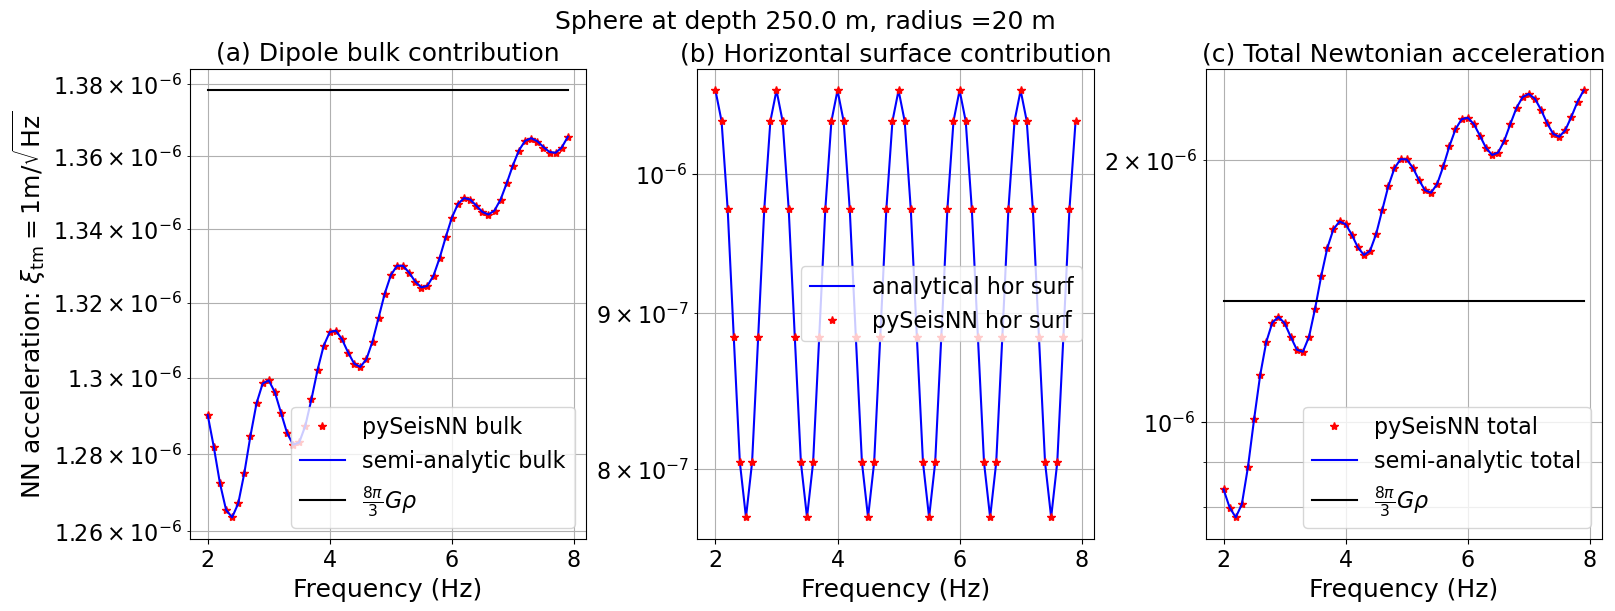

In [12]:
# run this cell immediately after the previous cell
# or adapt accordingly
import matplotlib.pyplot as plt
import scipy.constants as const
import numpy as np
import os
from modules import configLoader
from modules import bodyPSNN
from modules import plotUtils
configFile="/home/koley/CavityResults/SphereTutorialConfig/configParseHalfSpaceBodyHomo.ini"
config = configLoader.load_config(configFile)
data = np.load(os.path.join(config.outDispPathRea, "NNFullRea0.npz"))

Iblock = data["IBlockTot"]
Ivert  = data["IVertFaceTot"]
Ihor   = data["IHorFaceTot"]
Itot   = data["ITot"]
freqOut = data["freqOut"]

G = const.G
rho = config.rho[0]
vS = config.vS[0]
vP = config.vP[0]
rho = config.rho[0]

L = 2000.0
sphere_radius = 20
xi0 = 1.0
wType = 'Pz'
# depth of cavity center below the surface
cav_depth = 250.0
# cavity center in global coordinates
cav_center = np.array([0.0, 0.0, L - cav_depth])
outer_bounds = (-L, L,-L, L,-L, L)

# test mass at cavity center
tm = cav_center.copy()
tm_shift = np.array([0.0, 0.0, 0.0])   # example: no shift
tm = cav_center + tm_shift

if(wType=='SHy'):
    pieces = [bodyPSNN.SH_y_x_sphere_all_components_shifted(f,vS,outer_bounds=outer_bounds,sphere_center=cav_center,
                                                      sphere_radius=sphere_radius,tm=tm,n_mu=64,n_phi=128,n_r=64,)
                                                      for f in freqOut]
    compPlot = 0
elif(wType=='SHx'):
    pieces = [bodyPSNN.SH_x_y_sphere_all_components_shifted(f,vS,outer_bounds=outer_bounds,sphere_center=cav_center,
                                                            sphere_radius=sphere_radius,tm=tm,n_mu=64,n_phi=128,n_r=64,)
                                                            for f in freqOut]
    compPlot = 1
elif(wType=='SV'):
    pieces = [bodyPSNN.SV_x_z_sphere_all_components_shifted(f,vS,outer_bounds=outer_bounds,sphere_center=cav_center,
                                                            sphere_radius=sphere_radius,tm=tm,n_mu=64,n_phi=128,n_r=64,)
                                                            for f in freqOut]
    compPlot = 2
elif(wType=='Px'):
    pieces = [bodyPSNN.P_x_sphere_all_components_shifted(f,vP,outer_bounds=outer_bounds,sphere_center=cav_center,
                                                         sphere_radius=sphere_radius,tm=tm,n_mu=64,n_phi=128,n_r=64,)
                                                         for f in freqOut]
    compPlot = 0
else:
    pieces = [bodyPSNN.P_z_sphere_all_components_shifted(f,vP,outer_bounds=outer_bounds,sphere_center=cav_center,
                                                         sphere_radius=sphere_radius,tm=tm,n_mu=64,
                                                         n_phi=128,n_r=64,)
                                                         for f in freqOut]
    compPlot = 2

H_bulk  = np.array([p[0] for p in pieces])   # shape (nFreq, 3)
H_vert  = np.array([p[1] for p in pieces])
H_hor   = np.array([p[2] for p in pieces])
H_total = np.array([p[3] for p in pieces])

A_bulk  = G*rho*xi0*H_bulk
A_vert  = G*rho*xi0*H_vert
A_hor = G*rho*xi0*H_hor
A_total = G*rho*xi0*H_total

plotUtils.set_plot_style(style="large")
fig, ax = plt.subplots(1,3,figsize=(16,6), constrained_layout = True)
fig.suptitle('Sphere at depth ' + str(cav_depth) + ' m, radius =' + str(sphere_radius) + ' m')
# or plt.suptitle('Main title')
ax[0].semilogy(freqOut, np.abs(Iblock[:,compPlot,0]),'r*', label="pySeisNN bulk")
ax[0].semilogy(freqOut, np.abs(A_bulk[:,compPlot]),  "b-", label="semi-analytic bulk")
ax[0].semilogy(freqOut, 8*np.pi/3*G*rho*np.ones((len(freqOut),1)),'k',label = r'$\frac{8\pi}{3}G\rho$')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].legend()
ax[0].set_ylabel("NN acceleration: " + r"$\xi_{\mathrm{tm}} = 1 \mathrm{m}/\sqrt{\mathrm{Hz}}$")
ax[0].grid(True, which="both")
#ax[0].set_ylim(10**-7, 3*10**-6)
ax[0].set_title('(a) Dipole bulk contribution')


if(wType == 'Px' or wType == 'SHy' or wType == 'SHx'):
    ax[1].semilogy(freqOut, np.abs(A_vert[:,compPlot]), "b-", label = "analytical vert surf")
    ax[1].semilogy(freqOut, np.abs(Ivert[:,compPlot,0]), 'r*', label="pySeisNN vert surf")
else:
    ax[1].semilogy(freqOut, np.abs(A_hor[:,compPlot]), "b-", label = "analytical hor surf")
    ax[1].semilogy(freqOut, np.abs(Ihor[:,compPlot,0]), 'r*', label="pySeisNN hor surf")
ax[1].set_xlabel('Frequency (Hz)')
ax[1].legend()
ax[1].grid(True, which="both")
#ax[1].set_ylim(10**-7, 3*10**-6)
ax[1].set_title('(b) Horizontal surface contribution')

ax[2].semilogy(freqOut, np.abs(Itot[:,compPlot,0]), 'r*', label="pySeisNN total")
ax[2].semilogy(freqOut, np.abs(A_total[:,compPlot]), "b-", label="semi-analytic total")
ax[2].semilogy(freqOut, 8*np.pi/3*G*rho*np.ones((len(freqOut),1)),'k',label = r'$\frac{8\pi}{3}G\rho$')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].legend()
ax[2].grid(True, which="both")
#ax[2].set_ylim(10**-7, 3*10**-6)
ax[2].set_title('(c) Total Newtonian acceleration')
